# The Struggle of Registration within the University of Maryland CS Department
### Analysis by Nicholas Gratian, Summer Sheldon, and Paula Vinokur

# Introduction
As a UMD student, registration can be one of the most difficult times of the year. Having to balance your registration date, requirements, section times, and what professors are teaching to create your perfect schedule can be an almost impossible task. This even more true for CS students at UMD, where for most 400 level classes there is some combination of having only one section, [not nearly enough seats](https://www.reddit.com/r/UMD/comments/7d653p/cs_upper_level_courses_full/), or [too many professors](https://www.reddit.com/r/UMD/comments/lyn7xu/registration/) to pick from. There are also just a lot of upper levels to choose from, and it can be [difficult to narrow down](https://www.reddit.com/r/UMD/comments/mq9a43/cmsc_411_vs_423_vs_436_with_433/) which courses to take based on interest alone. As we have seen, many people turn to friends or strangers online to ask for their opinions, but these can vary greatly based on individual experience. 

For those of us who care most about maintaining both GPA and mental health, there must be an easier way. In order to help solve this problem, we aim to look at open source data hosted by both umd.io and planetterp.com to analyze professors within the Computer Science department and their grade data to see if there are relationships that can allow students to more easily choose when and how to fulfill their requirements. With such a large quantity of data available on this topic, using data science techniques to analyze and draw conclusions that will benefit students is essential.

# Data Gathering and Tidying
## Libraries
We will be using several essential libraries throughout this project in order to gather, tidy, and analyze our data
- requests: to interact with the apis necessary to import our data
- pandas: to store our data in an organized dataframe
- numpy: to further manipulate and aggregate our data
- matplotlib: to visualize our data and analysis
- seaborn: to add additional regression analysis 
- time: to sleep between requests
- statsmodels: to add advanced regression information

In [1]:
# Importing necessary modules
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Gathering Data

In order to obtain all the information we were interested in for this project, we needed to pull data from two main sources and their built in APIs. Using APIs have their [advantages](https://medium.com/api-world/using-an-api-for-web-scraping-a-list-of-the-best-advantages-586e9fec2660) in Data Science, as they are typically quick to start using and to integrate into the rest of your project. Web scraping can be more complex and result in data that requires more manipulation before analyzing. Our APIs of interest are:

### [UMD.io](https://umd.io/)
This api allows users to access open source data on various aspects of the University of Maryland, including the entire schedule of classes, section numbers, times, building numbers going back until 2017. Specifically for our purposes, we are interested in obtaining a list of all of the classes offered by the Computer Science department during this time.

### [Planet Terp](https://planetterp.com/)
This site similarly gathers and hosts data relevant to classes at the University of Maryland. However, this data is much more focused on grades. Specifically, overall course information and stats, individual professor grade distributions, and professor reviews. All of this data for those courses within CS is information we aim to analyze for our project.

**Note:** We are only using a small portion of the data available by these sites, and therefore just brushing the surface of potential conclusions! There is so much more that can be done with this data, so they make for a great starting point for your own projects :)

### Putting them together
A key aspect of the Planet Terp api is that you must query either a specified course or professor in order to recieve information. For this reason, we are first gathering a list of offered CS courses from UMD.io, and then will query PlanetTerp for more information on each of these courses.

In [2]:
# Initialize list to hold the data requested
cmsc_courses_list = []
# Initialize page counting variable to manage pagination
page = 1

# Loop to manage pagination of requests
# Each request only returns a maximum of 100 records per page, 
# so continue iterating through pages until all information is received
while (page_list := 
       requests.get(f"https://api.umd.io/v1/courses?dept_id=CMSC;per_page=100;page={page}").json()) != []:
    cmsc_courses_list.extend(page_list)
    page += 1

For a sanity check, we can see the first and last 10 classes we recieved from this request and see that they contain the entire course id range (100s - 800s)

In [3]:
print(f"First 10 courses: {[c['course_id'] for c in cmsc_courses_list[:10]]}")
print(f"Last 10 courses: {[c['course_id'] for c in cmsc_courses_list[-10:]]}")

First 10 courses: ['CMSC100', 'CMSC106', 'CMSC122', 'CMSC125', 'CMSC131', 'CMSC132', 'CMSC216', 'CMSC216H', 'CMSC250', 'CMSC250H']
Last 10 courses: ['CMSC828I', 'CMSC828L', 'CMSC828O', 'CMSC838C', 'CMSC838E', 'CMSC848Q', 'CMSC858D', 'CMSC858F', 'CMSC898', 'CMSC899']


### Cross Listed Courses
Aside from the courses explicitly listed under CMSC, there are also a small handful of courses which are cross listed as equivalent or identical classes to those in Computer Science. These are:
- CMSC475 / MATH475
- CMSC456 / MATH456
- CMSC460 / AMSC460
- CMSC466 / AMSC466

With the way that Planet Terp stores information on these classes, we would need to request information for the primary id associated with the class, which for the classes above are the secondary MATH/AMSC listings. For the sake of our project, we have decided to omit this analysis for the sake of time and simplicity, as they more closely are associated with departments other than Computer Science and therefore may have different trends.

In [4]:
cross_listed_courses = ['MATH475', 'MATH456', 'AMSC460', 'AMSC466']

### Getting Grade Data
Now that we have a list of what courses we are interested in, we can move onto requesting data from Planet Terp. Data is split up into two silos. The first of which is overall information on these courses, including section times and teaching professors. The second is more specific information on grades when a single professor taught a specific course.

We will start by requesting this general information on each of our CS classes in order to get an accurate list of who has taught each course.

In [5]:
# Use the list of courses from umd.io to request additional information from Planet Terp
course_info = []
for course in cmsc_courses_list:
    course_info.append(requests.get(f"https://api.planetterp.com/v1/course?name={course['course_id']}").json())

Due to the quantity of information, we limit our scope of analysis to just the undergraduate classes. These consist of all CMSC courses with IDs between 100 and 499. From this classes, we will create our first dataframe to more easily access the columns of interest.

In [6]:
# Get dataframe of just undergrad cs course info
course_info = pd.DataFrame(course_info).dropna(axis=0, subset=["department", "course_number"])
ugrad_course_data = course_info[[int(cid[0]) <= 4  for cid in course_info["course_number"]]]
ugrad_course_data.head()

,department,course_number,title,description,credits,professors,average_gpa,error
0,CMSC,100,Bits and Bytes of Computer and Information Sci...,<b>Restriction:</b> For first time freshmen an...,1.0,"[Charles Kassir, Amy Vaillancourt, Alyssa Neun...",3.37743,NaN
1,CMSC,106,Introduction to C Programming,<b>Prerequisite:</b> MATH115.\n<b>Restriction:...,4.0,"[Nelson Padua-Perez, Ilchul Yoon, Anthony Bane...",2.26272,NaN
2,CMSC,122,Introduction to Computer Programming via the Web,<b>Restriction:</b> Must not have completed an...,3.0,"[Fawzi Emad, Pedram Sadeghian, Jandelyn Plane,...",2.46786,NaN
3,CMSC,125,Introduction to Computing,<b>Prerequisite:</b> Must have completed or be...,3.0,[Elias Gonzalez],NaN,NaN
4,CMSC,131,Object-Oriented Programming I,<b>Corequisite:</b> MATH140.\n<b>Credit only g...,4.0,"[Jandelyn Plane, Fawzi Emad, Evan Golub, Thoma...",2.42284,NaN


The primary column we care about from the above table is the professors column for each row. From this, we are able to iterate through the list of professors that have taught each course, and collect a DataFrame of grade information.

Planet Terp has a method of distinguishing between professors by assigning each of them a unique [slug](https://api.planetterp.com/#planetterp-api-professors), which is typically but not always said professor's last name. Since we cannot guarantee this slug value based solely on name, or that we have the exact spelling or format of the professor's name to begin with, we must use Plant Terp's search query to first see if they have information.

Occasionally, Planet Terp does not have record of the professor we are querying. This is most likely due to specialty courses such as [CMSC499A](https://undergrad.cs.umd.edu/research-professorial-faculty-cmsc499a) where grades are more individualized and class sections are not well defined. We will choose to ignore these sections in our data since registration for these courses is most likely not mandatory or based on grade information.

In [7]:
# Initialize list to store grade data from Planet Terp
course_data_df = []

# Iterate through each undergrad CS course
for idx, row in ugrad_course_data.iterrows():
    # Get the course id and list of professors
    course = row['course_number']
    profs = row['professors']
    
    # Iterate through the list of professors
    for prof in profs:
        # Sleep to allow time between API requests
        time.sleep(1)
        
        # Search for professor and gather grade information if response is not empty
        prof_info = requests.get(f"https://api.planetterp.com/v1/search?query={prof}").json()
        if len(prof_info) != 0:
            name = prof_info[0]["name"] 
            course_data_df.extend(requests.get(f"https://api.planetterp.com/v1/grades?course=CMSC{course}&professor={name}").json())

### Saving the Data
In order to not overwhelm the Planet Terp servers by rerequesting the same information repetadly, we decided to download our compiled, untidied dataframe in to a csv file. This way we are able to simply load from a file instead of repeating the many requests to reassemble our data. When loading the data, an unnamed column is mistakenly loaded in using the index data, despite the table addding a new index column anyway. For this reason, dropping this column is necessary if you are deciding to load the data from this file instead of gathering it from the sources.

In [22]:
# Export data as a CSV file
course_data_df = pd.DataFrame(course_data_df)
course_data_df.to_csv('course_data.csv')

course_grade_data = course_data_df

**Note: The first time you are running this tutorial and you have just created a csv file, you can skip the block below and continue on with the data you have. All future times, you can import the necessary libraries and then begin execution here moving forward. Data will be read from the saved CSV.**

In [7]:
# Read the data from a CSV instead of from requests,
course_grade_data = pd.read_csv('course_data.csv')
course_grade_data = course_grade_data.drop('Unnamed: 0', axis = 1)

This is a preview of our complete untidied data frame! As shown below, each row represents an individual section of a course taught, listing the given semester, professor, and course id. 

Semesters are represented using 6 digit semester ids, where the first 4 digits are the year of study, and the last 2 digits represent either Spring or Fall. 01 represents Spring semesters, since they start in January, and 08 represents Fall semesters that start in late August. For example, semester 202101 is Spring 2021.

Additionally in this DataFrame, the data of interest is finally gathered with raw counts of how many students recieved which grade for each row. Information on how UMD assigns these grades and their values can be found [here](https://registrar.umd.edu/current/Policies/acadregs.html).

These grade values are measured on a typical 4.0 GPA and range from A+ to D-, and then also includes F, which is how many students recieved below a D- grade and therefore did not pass, and W, which is the count of students that dropped the course after the traditional drop add period. The final column, Other, is how many students opted to take the course Pass Fail and recieved a pass, instead of the traitional grade. Typically this count is very low since students have a low limit of how many credits they can take with this method during their studies. However, during Spring 2020 and Spring 2021 semesters, students were able to take any course they wanted P/F without consequence, so the count is much higher.

In [8]:
course_grade_data

,course,professor,semester,section,A+,A,A-,B+,B,B-,C+,C,C-,D+,D,D-,F,W,Other
0,CMSC100,Charles Kassir,201408,0101,19,9,1,2,0,3,0,0,1,0,0,0,1,1,0
1,CMSC100,Amy Vaillancourt,201808,0101,14,1,0,0,1,0,0,0,0,0,0,0,0,1,0
2,CMSC100,Amy Vaillancourt,201708,0101,9,4,2,0,0,0,0,0,0,0,0,0,0,2,0
3,CMSC100,Amy Vaillancourt,201608,0101,17,6,2,3,2,1,2,0,1,1,1,0,2,0,0
4,CMSC100,Amy Vaillancourt,201508,0101,20,5,5,5,3,1,3,1,0,0,0,0,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2058,CMSC470,Rachel Rudinger,202101,0101,6,29,14,6,5,2,1,1,1,0,1,0,0,2,12
2059,CMSC498F,Cornelia Fermuller,201701,0101,6,4,2,1,3,3,1,1,0,0,0,0,0,7,0
2060,CMSC498F,Cornelia Fermuller,201601,0101,9,8,9,3,4,2,0,0,0,0,0,0,0,5,1
2061,CMSC498T,Hector Corrada Bravo,201501,0101,7,4,8,5,0,4,0,3,1,0,0,0,0,3,0


## Tidying the Data
Now we were ready to tidy the data. As it stands, the table is very dense with many rows for each professor and each each class within a semester. Professors often teach multiple sections of the same course in a semester, so we decided to aggregate all of the sections within a semester into a single row. 

To do this, we grouped the data by course, professor, and semester and calculated the sum of the number of different types of grades values (A+,A,A-,..., Other)

In [9]:
tidied = course_grade_data.groupby(['course', 'professor','semester']).agg({'A+':['sum'], 'A':['sum'], 'A-':['sum'], 
                                                                            'B+':['sum'], 'B':['sum'], 'B-':['sum'],
                                                                            'C+':['sum'], 'C':['sum'], 'C-':['sum'],
                                                                            'D+':['sum'], 'D':['sum'], 'D-':['sum'], 
                                                                            'F':['sum'], 'W':['sum'], 'Other':['sum']})
tidied.columns = ['A+', 'A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D+', 'D', 'D-','F', 'W', 'Other']
tidied = tidied.reset_index()
tidied.head()

,course,professor,semester,A+,A,A-,B+,B,B-,C+,C,C-,D+,D,D-,F,W,Other
0,CMSC100,Alyssa Neuner,201708,14,0,0,2,0,0,0,0,0,1,0,0,0,1,0
1,CMSC100,Alyssa Neuner,201808,0,12,0,2,0,0,0,0,0,0,0,0,0,0,0
2,CMSC100,Amy Vaillancourt,201508,20,5,5,5,3,1,3,1,0,0,0,0,3,1,0
3,CMSC100,Amy Vaillancourt,201608,17,6,2,3,2,1,2,0,1,1,1,0,2,0,0
4,CMSC100,Amy Vaillancourt,201708,9,4,2,0,0,0,0,0,0,0,0,0,0,2,0


We then decided to add several additional columns to the table, starting simply with average GPA received in the class. This was calculated using values on a traditional 4.0 scale, with additional information again shared [here](https://registrar.umd.edu/current/Policies/acadregs.html).

In [10]:
avg_gpa = []
for idx, row in tidied.iterrows():
    row_total = row['A+'] + row['B+'] + row['C+'] + row['D+'] + row['A']  + row['B']  + row['C']  + row['D'] \
                    + row['A-'] + row['B-'] + row['C-'] + row['D-'] + row['F'] 
    weighted_calc = row['A+'] * 4.0 + row['B+'] * 3.3 + row['C+'] * 2.3 + row['D+'] * 1.3 + row['A'] * 4.0 +  \
                    row['B'] * 3.0 + row['C'] * 2.0 + row['D'] * 1.0 + row['A-'] * 3.7 + row['B-'] * 2.7 + \
                    row['C-'] * 1.7 + row['D-'] * 0.7 + row['F'] * 0 
    avg_gpa.append((weighted_calc/row_total))
    
tidied['average gpa'] = avg_gpa
tidied.head()

,course,professor,semester,A+,A,A-,B+,B,B-,C+,C,C-,D+,D,D-,F,W,Other,average gpa
0,CMSC100,Alyssa Neuner,201708,14,0,0,2,0,0,0,0,0,1,0,0,0,1,0,3.758824
1,CMSC100,Alyssa Neuner,201808,0,12,0,2,0,0,0,0,0,0,0,0,0,0,0,3.900000
2,CMSC100,Amy Vaillancourt,201508,20,5,5,5,3,1,3,1,0,0,0,0,3,1,0,3.382609
3,CMSC100,Amy Vaillancourt,201608,17,6,2,3,2,1,2,0,1,1,1,0,2,0,0,3.331579
4,CMSC100,Amy Vaillancourt,201708,9,4,2,0,0,0,0,0,0,0,0,0,0,2,0,3.960000


The rest of the factors we are interested in looking at depend on how long a given professor has taught before. The first is how many times a professor has taught the same class before teaching the given semester, and the second is how many semesters they have previously taught in the Computer Science department, regardless of what class. Both of these rely on counting previous occurences of a single professor within the dataframe.

In [11]:
# Count how many times a professor has taught this course before
tidied['prev semesters taught this course'] = tidied.sort_values('semester').groupby(['course','professor']).cumcount()

In [12]:
# Define function to count how many semesters a professor has taught in CS before
# Parameter group1 is a slice of the dataframe consisting of data for a single professor
# Returns a list of values that can be used to set a new df column
def semesters_at_umd_count(group1):
    semester_count = 0
    counts = []
    # Iterate through each unique semester value and extend list with the appropriate data
    for key, group2 in group1.groupby('semester'):
        counts.extend([semester_count]*len(group2))
        semester_count+=1
    return counts

semester_counts = []
# Call semesters_at_umd_count on each professor's data
for k, group1 in tidied.groupby(['professor']):
    semester_counts.extend(semesters_at_umd_count(group1))

# Sort original dataframe so semester_count values line up correctly
tidied = tidied.sort_values(["professor", "semester"])

# Add data in new column 
tidied["prev semesters in cmsc"] = semester_counts

We now have our final, tidied, aggregate dataframe containing information on each professor for each class they have taught. With this, we can finally move on to analyzing our data and attempting to find any relationships or shortcuts that students can use to their advantage when registering. 

In [13]:
tidied

,course,professor,semester,A+,A,A-,B+,B,B-,C+,...,C-,D+,D,D-,F,W,Other,average gpa,prev semesters taught this course,prev semesters in cmsc
300,CMSC412,A.U. Shankar,201201,2,10,0,5,8,0,4,...,2,0,1,0,3,2,0,2.823077,0,0
301,CMSC412,A.U. Shankar,201208,0,8,6,4,6,0,0,...,3,0,0,0,0,2,0,3.106061,1,1
318,CMSC414,A.U. Shankar,201301,6,2,4,0,10,10,0,...,7,0,2,0,1,2,0,2.717021,0,2
302,CMSC412,A.U. Shankar,201308,4,2,2,2,4,3,0,...,2,0,0,0,8,4,10,2.277778,2,3
319,CMSC414,A.U. Shankar,201408,1,9,0,7,8,3,2,...,1,0,2,0,0,1,0,2.937500,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,CMSC422,William Regli,201808,16,17,9,8,6,4,2,...,4,0,0,0,0,4,0,3.447826,0,0
430,CMSC421,William Regli,202008,15,11,14,33,23,15,13,...,2,0,0,0,4,12,0,3.084559,0,1
661,CMSC457,Xiaodi Wu,201801,2,7,3,2,7,4,3,...,3,1,0,0,0,5,0,2.994286,0,0
662,CMSC457,Xiaodi Wu,202001,3,4,6,3,2,0,0,...,0,0,0,0,2,7,22,3.305000,1,1


# Analysis

Now we can start exploring the data to see what types of relationships exist within the data.

We wanted to collect all of the data regarding the upper level courses which we defined as any course that starts with "CMSC4".

In [14]:
# Use regex to match all of the rows with courses that start with "CMSC4"
upper_levels = tidied[tidied['course'].str.contains(r'^CMSC4')] 
upper_levels.head()

,course,professor,semester,A+,A,A-,B+,B,B-,C+,...,C-,D+,D,D-,F,W,Other,average gpa,prev semesters taught this course,prev semesters in cmsc
300,CMSC412,A.U. Shankar,201201,2,10,0,5,8,0,4,...,2,0,1,0,3,2,0,2.823077,0,0
301,CMSC412,A.U. Shankar,201208,0,8,6,4,6,0,0,...,3,0,0,0,0,2,0,3.106061,1,1
318,CMSC414,A.U. Shankar,201301,6,2,4,0,10,10,0,...,7,0,2,0,1,2,0,2.717021,0,2
302,CMSC412,A.U. Shankar,201308,4,2,2,2,4,3,0,...,2,0,0,0,8,4,10,2.277778,2,3
319,CMSC414,A.U. Shankar,201408,1,9,0,7,8,3,2,...,1,0,2,0,0,1,0,2.937500,1,4


This resulted in 396 rows. As such we we were curious to find out how many unique courses and professors are included in this group.

In [15]:
print(f"Within the 400 level courses:")
print(f" - there are {len(upper_levels['course'].unique())} unique courses")
print(f" - there are {len(upper_levels['professor'].unique())} unique professors")

Within the 400 level courses:
 - there are 25 unique courses
 - there are 86 unique professors


### Note:
One method of beginning to analyze and visualize the data would be to plot each course seperately. This could highlight trends between different courses and create different student strategies when registering. Below is an example of this visualization using CMSC420 as a sample.

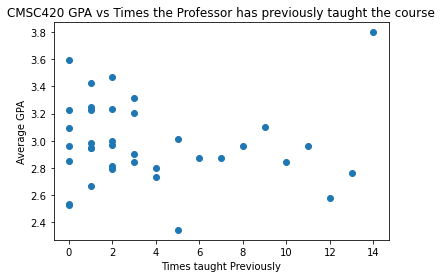

In [16]:
# First get the subset of all the rows that have data regarding CMSC420 and save that in cmsc420
cmsc420 = tidied[tidied['course'] == 'CMSC420']

# Then, we want to plot the number of previous semester a professor has taught the course and the average gpa.
# So we set the corresponding columns to the x and y variables respectively.
x = cmsc420['prev semesters taught this course']
y = cmsc420['average gpa']

plt.scatter(x,y)
plt.title("CMSC420 GPA vs Times the Professor has previously taught the course")
plt.xlabel("Times taught Previously")
plt.ylabel("Average GPA")
plt.show()

                          Figure a

However, there are a lot of combinations with 25 courses and 86 professors, so we wanted a way to group courses. Luckily, the CMSC department has a strategy already.

## Examining Upper Level Areas

Courses are grouped into areas, and there are certain requirements for undergraduate degrees in terms of the number of courses a student can take within an area and across areas. 

These areas are:
1. Systems
2. Information Processing
3. Software Engineering and Programming Languages
4. Theory
5. Numerical Analysis

More information regarding the general track can be found [here](https://undergrad.cs.umd.edu/general-track-degree-requirements)

The following code blocks group the courses from the upper_levels dataframe into smaller dataframes for further analysis.

In [17]:
area_1 = upper_levels[upper_levels['course'].isin(
    ['CMSC411','CMSC412','CMSC414','CMSC416','CMSC417','CMSC498X','CMSC498X','CMSC498K'])]
print(f"Area 1 Average GPA: {round(np.mean(area_1['average gpa']), 3)}")

Area 1 Average GPA: 2.863


In [18]:
area_2 = upper_levels[upper_levels['course'].isin(
    ['CMSC420','CMSC421','CMSC422','CMSC423','CMSC424','CMSC426',
     'CMSC427','CMSC470','CMSC471','CMSC498F','CMSC498V', 'CMSC471'])]
print(f"Area 2 Average GPA: {round(np.mean(area_2['average gpa']), 3)}")

Area 2 Average GPA: 3.125


In [19]:
area_3 = upper_levels[upper_levels['course'].isin(
    ['CMSC430','CMSC433','CMSC434','CMSC435','CMSC436','CMSC471'])]
print(f"Area 3 Average GPA: {round(np.mean(area_3['average gpa']), 3)}")

Area 3 Average GPA: 3.173


In [20]:
area_4 = upper_levels[upper_levels['course'].isin(
    ['CMSC451','CMSC452','CMSC454','CMSC456','CMSC457','CMSC474'])]
print(f"Area 4 Average GPA: {round(np.mean(area_4['average gpa']), 3)}")

Area 4 Average GPA: 2.976


In [21]:
area_5 = upper_levels[upper_levels['course'].isin(['CMSC460','CMSC466'])]
area_5

,course,professor,semester,A+,A,A-,B+,B,B-,C+,...,C-,D+,D,D-,F,W,Other,average gpa,prev semesters taught this course,prev semesters in cmsc


Since Area 5 consists exclusively of cross listed courses (MATH and AMSC), we will not be including Area 5 in our analysis for the reasons discussed earlier. Our focus is on CMSC classes only.

In [22]:
electives = upper_levels[upper_levels['course'].isin(
    ['CMSC425','CMSC472','CMSC473','CMSC475','CMSC498','CMSC498A' ,'CMSC499A'])]
print(f"Electives Average GPA: {round(np.mean(electives['average gpa']), 3)}")

Electives Average GPA: 3.458


The following code block creates 5 plots for each of the areas. 

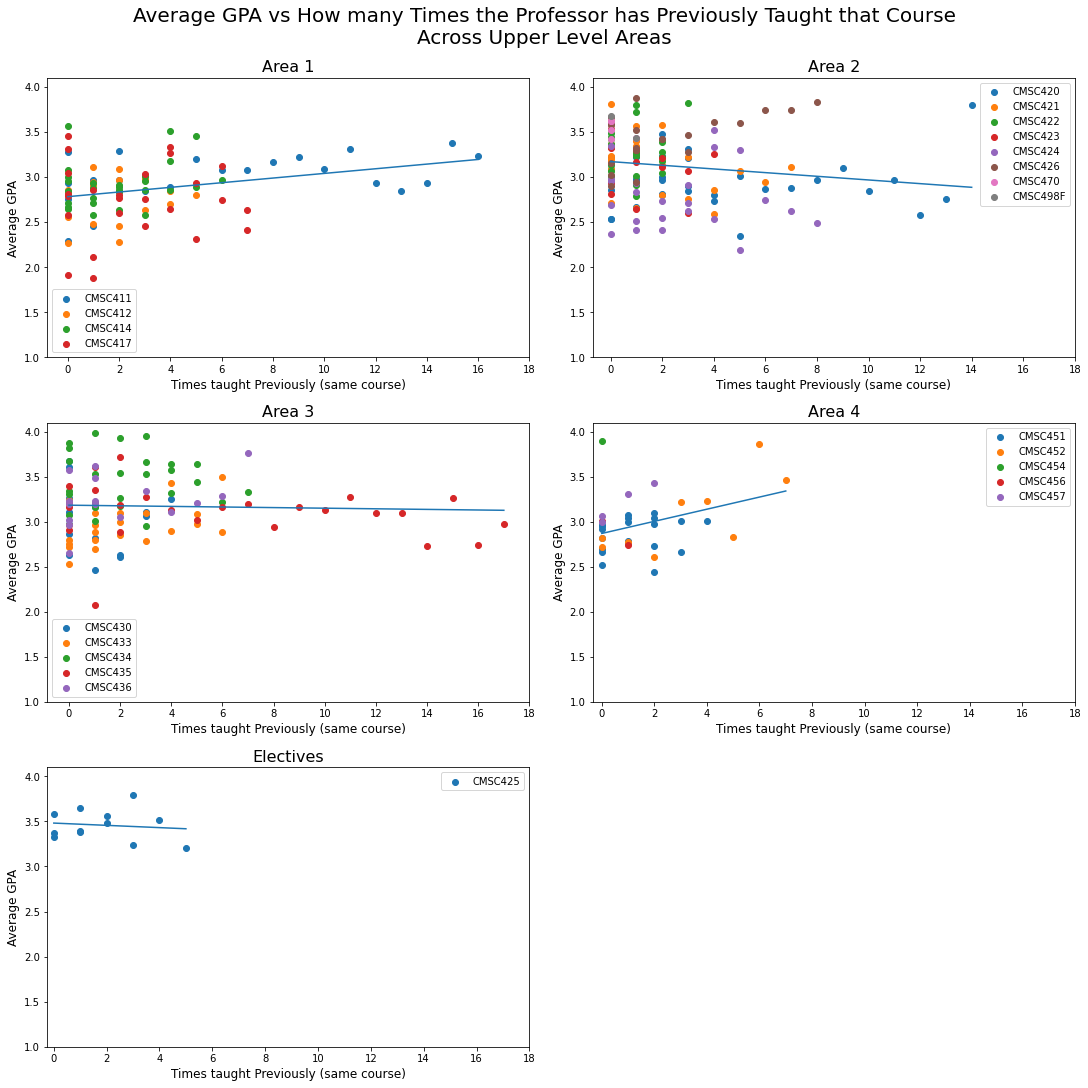

In [23]:
# Use a list of the different areas to iterate over the different dataframes
areas = [area_1, area_2, area_3, area_4, electives]

# Create subplots for each of the different areas
fig, ax = plt.subplots(3,2, figsize=(15,15), constrained_layout=True)
ax = ax.flatten()
ax[-1].axis(False)

i = 0
areaNum = 1

for area in areas:
    # For the linear regression, we need to store all of the times a professor previously taught a course 
    # and all of the corresponding average GPAs. These are kept in the total_tt and total_ag lists.
    total_tt = []
    total_ag = []
    
    # For each of the courses within an area, we want to pull the necessary columns out of the dataframe and plot it
    for key, course in area.groupby('course'):
        x = course['prev semesters taught this course']
        y = course['average gpa']
        ax[i].scatter(x,y, label = key)
        total_tt.extend(x)
        total_ag.extend(y)
        
    # These following lines will create the linear regression
    z = np.polyfit(total_tt, total_ag, 1)
    p = np.poly1d(z)
    xp = np.linspace(0, max(area['prev semesters taught this course']), 100)
    
    ax[i].plot(xp, p(xp))
    
    ax[i].legend()
    
    ax[i].set_ylim(1.0,4.1)
    ax[i].set_xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18])
    ax[i].set_title(f"Area {areaNum}", fontsize=16)
    ax[i].set_xlabel("Times taught Previously (same course)", fontsize=12)
    ax[i].set_ylabel("Average GPA", fontsize=12)
    
    i += 1
    areaNum += 1
    
fig.suptitle("Average GPA vs How many Times the Professor has Previously Taught that Course\nAcross Upper Level Areas"
             , fontsize=20)
# the Electives area does not follow the pattern so we manually provide the title
ax[-2].set_title("Electives", fontsize=16) 
plt.show()

            Figure b (Area 1),  Figure c (Area 2),  Figure d (Area 3),  Figure e (Area 4),  Figure f (Electives)

For each of the areas, the plots are the number of semesters a professor previously taught the class against the average GPA for that class and professor combination.

Based off the above plots, the Area 1 and Area 4 courses' average GPAs increase as a professor teaches a course more. However, Area 2 and Electives tend to decrease as a professor gains experience with a class. The Area 3 courses decrease but slower than the previously mentioned groups do. 

These plots show that average GPAs do not necessarily respond the same depending on how many semesters a professor teaches a specific class.

## Comparing the Upper Level Courses with the Required Lower Level Courses

In addition to the upper levels, CMSC students are required to take 6 courses before starting the upper levels. As such we created a dataframe that contains all of the tided data for CMSC131, CMSC132, CMSC216, CMSC250, CMSC330, and CMSC351.

In [24]:
req_lower_levels = tidied[tidied['course'].isin(["CMSC131", "CMSC132", "CMSC216", 
                                                             "CMSC250", "CMSC330", "CMSC351"])]

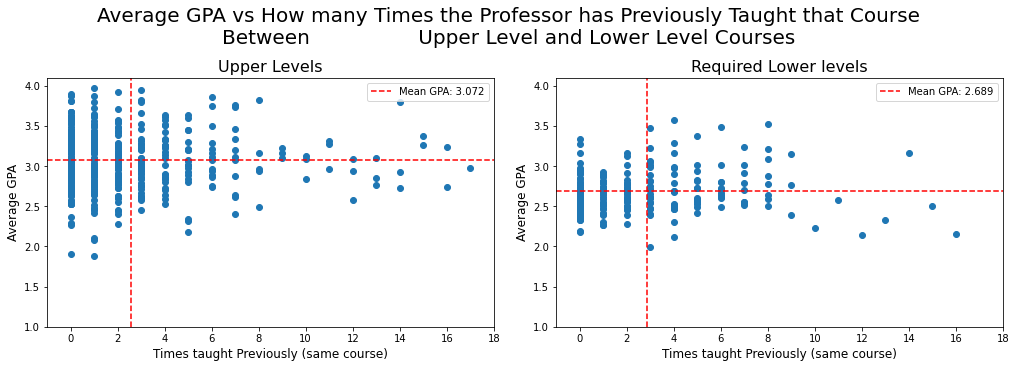

In [25]:
# Create two subplots for the 400 level and required lower level courses
fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for idx, grp in enumerate([upper_levels, req_lower_levels]):
    ax[idx].scatter(grp["prev semesters taught this course"], grp["average gpa"])

    # Plot the average of the average gpa and number of semesters a professor taught the course to provide more insight
    ax[idx].axhline(np.mean(grp["average gpa"]), color="red",linestyle="--", 
                    label=f"Mean GPA: {np.round(np.mean(grp['average gpa']), 3)}")
    ax[idx].axvline(np.mean(grp["prev semesters taught this course"]), color="red",linestyle="--")
    
    ax[idx].set_xlim((-1,18))
    ax[idx].set_ylim((1, 4.1))
    ax[idx].set_xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18]) 
    ax[idx].set_xlabel("Times taught Previously (same course)", fontsize=12)
    ax[idx].set_ylabel("Average GPA", fontsize=12)
    ax[idx].legend()

ax[0].set_title("Upper Levels", fontsize=16)
ax[1].set_title("Required Lower levels", fontsize=16)

fig.suptitle("Average GPA vs How many Times the Professor has Previously Taught that Course\nBetween \
                Upper Level and Lower Level Courses", fontsize=20)

plt.show()

                         Figure g                                            Figure h

The above plots show the differences of how the relationships between the average GPA and number of semesters a professor taught the corresponding course between the upper level courses and the required lower levels.

The plots show that the upper level courses have a higher average grade in comparison to the required lower levels.

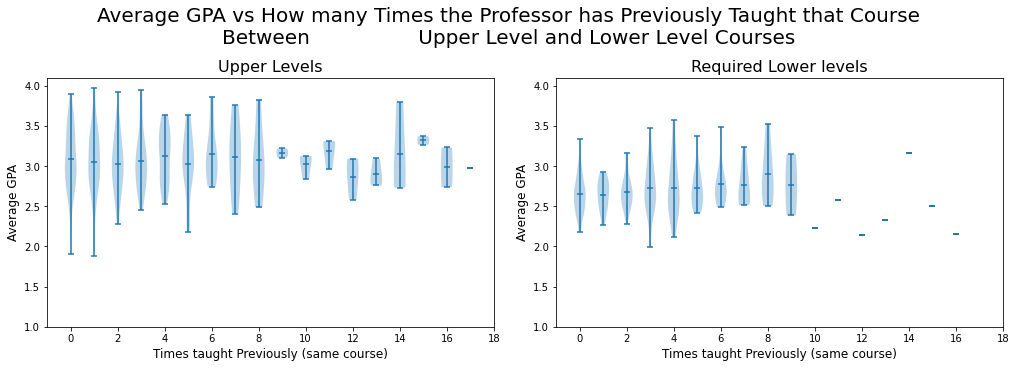

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Create two subplots for the 400 level and required lower level courses
for idx, grp in enumerate([upper_levels, req_lower_levels]):
    times_taught = grp["prev semesters taught this course"].unique()
    grades = []
    for amt in times_taught:
        # A list of all the average GPAs for the rows where the number of previous semesters a professor 
        # taught this course is equal to amt (or the number of times) we are currently looking at gets
        # appended to grades
        temp = list(grp[grp["prev semesters taught this course"] == amt]["average gpa"])
        grades.append(temp)
        
    ax[idx].violinplot(grades, times_taught, showmeans=True)
    
    ax[idx].set_xlim((-1,18))
    ax[idx].set_ylim((1, 4.1))
    ax[idx].set_xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18])
    ax[idx].set_xlabel("Times taught Previously (same course)", fontsize=12)
    ax[idx].set_ylabel("Average GPA", fontsize=12)

ax[0].set_title("Upper Levels", fontsize=16)
ax[1].set_title("Required Lower levels", fontsize=16)
fig.suptitle("Average GPA vs How many Times the Professor has Previously Taught that Course\nBetween \
                Upper Level and Lower Level Courses", fontsize=20)

plt.show()

                         Figure i                                                           Figure j

Although these plots contain the same data as the scatterplot, these plots demonstrate the spread of average GPAs for the number of times a professor previously taught the same course. 

In *Figure i*, the spread of the average GPAs decreases as the number of times a professor teaches a course. 

However, in *Figure j*, there is a smaller spread of GPAs. Also, once the number of times for these classes is greater than 10 there is no range of average GPAs. Rather than violin plots these are just points.

## Looking at Teaching Experience vs Average Grade

After seeing no general patterns with the number of times a professor teaches a course and the average GPA, we wanted to see if there was a relationship between the number of semesters they spent teaching within CMSC at UMD and the average GPA for the course.

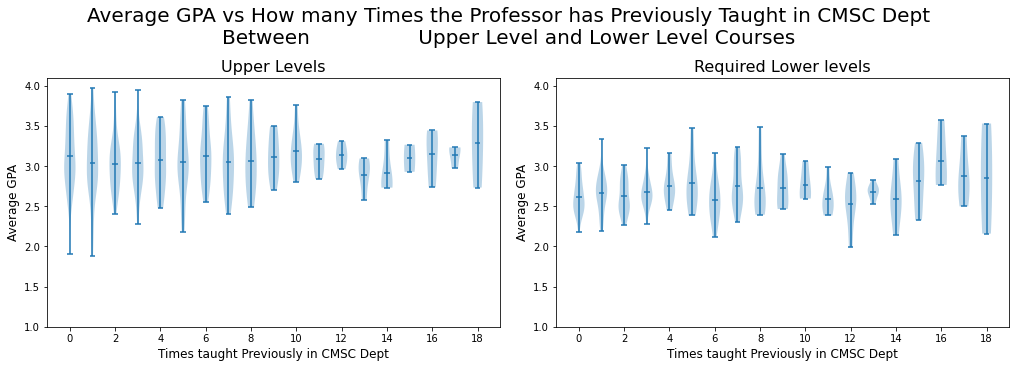

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Create two subplots for the 400 level and required lower level courses
for idx, grp in enumerate([upper_levels, req_lower_levels]):
    times_taught = grp["prev semesters in cmsc"].unique()
    grades = []
    for amt in times_taught:
        # Append all of the average GPAs for rows where the number of previous semesters a professors has been 
        # in the CMSC department to grades
        grades.append(grp[grp["prev semesters in cmsc"] == amt]["average gpa"])

    ax[idx].violinplot(grades, times_taught, showmeans=True)
    
    ax[idx].set_xlim((-1,19))
    ax[idx].set_ylim((1, 4.1))
    ax[idx].set_xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18])
    ax[idx].set_xlabel("Times taught Previously in CMSC Dept", fontsize=12)
    ax[idx].set_ylabel("Average GPA", fontsize=12)

ax[0].set_title("Upper Levels", fontsize=16)
ax[1].set_title("Required Lower levels", fontsize=16)
fig.suptitle("Average GPA vs How many Times the Professor has Previously Taught in CMSC Dept\nBetween \
                Upper Level and Lower Level Courses", fontsize=20)


plt.show()

                         Figure k                                                             Figure l

On the left plot, *Figure k*, as a professor gains teaching experiences the spread of average GPAs decreases. On the other hand, the spread of required lower levels increases as the professor teaches more *Figure l*. 

It is interesting the relationships are opposites for the two different groups of CMSC classes.

## Looking into Average GPAs over Time

Then, we wanted to see if there any general trends within the CMSC department as time has gone on.

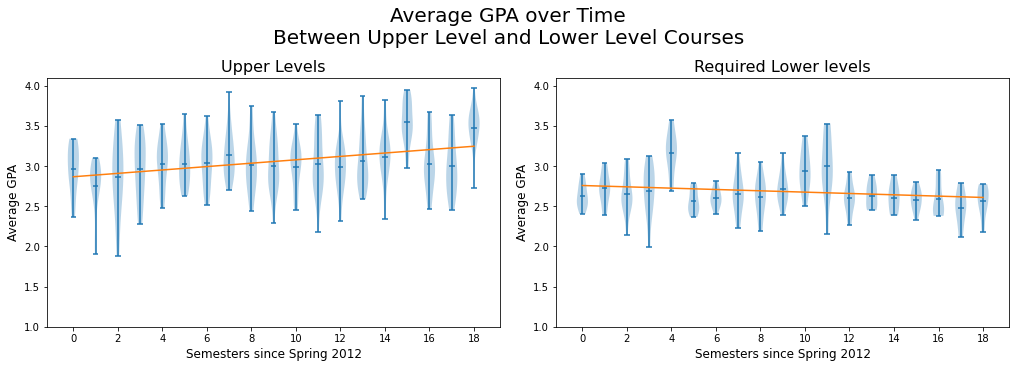

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Create 2 lists of lists, one to hold a list of the semesters for the upper level and lower level courses and the average
# GPAs for the upper level and lower level courses

# Index 0 refers to the upper level data and 1 to the lower level course data
agg_semesters = [[], []]
agg_average_grades = [[], []]

for idx, grp in enumerate([upper_levels, req_lower_levels]):
    semesters = grp["semester"].unique()
    grades = []
    
    for i, amt in enumerate(semesters):
        # Append all of the average GPAs for the current amt (semester) to grades
        temp = list(grp[grp["semester"] == amt]["average gpa"])
        grades.append(temp)
        
        agg_average_grades[idx].extend(temp) # Add all of the elements in temp to agg_average_grades
        agg_semesters[idx].extend([i]*len(temp)) # Add a list that contains temp number of the value i to agg_semesters
    
    ax[idx].violinplot(grades, list(range(len(times_taught))), showmeans=True)

    # Create a regression line using agg_semesters and agg_average_grades
    z = np.polyfit(agg_semesters[idx], agg_average_grades[idx], 1)
    p = np.poly1d(z)
    xp = np.linspace(0, 18, 100)
    ax[idx].plot(xp, p(xp))
    
    # Format plots
    ax[idx].set_ylim((1, 4.1))
    ax[idx].set_xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18])
    ax[idx].set_xlabel("Semesters since Spring 2012", fontsize=12)
    ax[idx].set_ylabel("Average GPA", fontsize=12)

ax[0].set_title("Upper Levels", fontsize=16)
ax[1].set_title("Required Lower levels", fontsize=16)

fig.suptitle("Average GPA over Time\nBetween Upper Level and Lower Level Courses", fontsize=20)


plt.show()

                         Figure m                                            Figure n

**Note:** The x axis of the above graph is measured in semesters since the first recorded semester, Spring 2012. For example, 2 represents two semesters after which would be Spring 2013. The final semester with recorded grades is Spring 2021. 

Once again there are opposite relationships between the two groups of courses within CMSC. As time has continued, the average GPAs for the upper level courses have increased. However, it has decreased in the lower levels. It appears that the lower levels have gotten harder over time. It is interesting to point out that the CMSC program at UMD has become a limited enrollment program, which may impact the lower levels especially.

# Predicting Future Grades

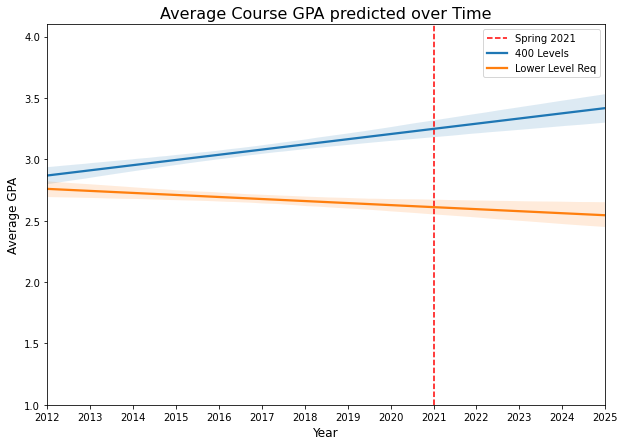

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
# plt.plot(xp, p_ul(xp), label="400 Levels")
# plt.plot(xp, p_ll(xp), label="Lower Level Requirements")

plt.axvline(18, color='red', linestyle="--", label="Spring 2021")

plt.title("Average Course GPA predicted over Time", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average GPA", fontsize=12)
ax.set_ylim(1.0, 4.1)
ax.set_xlim(0, 26)
plt.xticks([2*x for x in range(14)], list(range(2012, 2026)))

# Use seaborn.regplot to plot the regression lines for the upper level and lower levels using the lists of lists 
# created above
sns.regplot(x=agg_semesters[0], y=agg_average_grades[0], scatter=False, truncate=False, label="400 Levels")
sns.regplot(x=agg_semesters[1], y=agg_average_grades[1], scatter=False, truncate=False, label="Lower Level Req")

plt.legend()

plt.show()

                                      Figure o

Based off the plot above, the regression line predicts that as time continues the average GPA for 400 level courses will increase and the average GPA for the lower level courses will decrease. 

Based off the GPAs, it appears that that the CMSC program will be harder during the first sequence of courses. This makes sense due to the fact that CMSC has become a limited enrollment program. As such, it will be harder for student to stay in the program from the start.

# Analyzing our Regression

After creating these regressions using several factors to predict the GPA of a class, we wanted to further analyze the accuracy of these models and see how strong they are at actually predicting the data. For this, we relied heavily on the [statsmodels](https://www.statsmodels.org/stable/index.html) library, which provides a detailed summary of a model's fit once it is created. This summary includes [R^2 values](https://en.wikipedia.org/wiki/Coefficient_of_determination) for the model, [p values](https://en.wikipedia.org/wiki/P-value) for each coefficient, and more.

To begin, we needed to rename several columns in our dataframe to accomade the library, since spaces in columns are not compatible.

In [30]:
# Made copies of relevant Data Frames
tcopy = tidied.copy()
uppercopy = upper_levels.copy()
lowercopy = req_lower_levels.copy()

# List of new column names that do not include spaces
cols = ['course', 'professor', 'semester', 'A+', 'A', 'A-', 'B+', 'B', 'B-',
       'C+', 'C', 'C-', 'D+', 'D', 'D-', 'F', 'W', 'Other', 'average_gpa',
       'prev_this_course', 'prev_cmsc']

# Rename the columns in the new DataFrame copies
tcopy.columns = cols
uppercopy.columns = cols
lowercopy.columns = cols

### Simpler Model

The first model we want to analyze is the Average GPA over Time regression displayed in the plot above. To do this, we recreate the model using statsmodels and display both the parameters and the summary. This model is very simple and uses semester as the sole predictor for average GPA. We are also repeating this process for both the Upper Level and Lower Level subsets seperately.

In [31]:
# Analysis for plot above, upper level semester vs grade
UL_semesters = smf.ols(formula='average_gpa ~ semester', data=uppercopy).fit()
UL_semesters_summary = UL_semesters.summary()
print("Upper Level Rsquared: ", np.round(UL_semesters.rsquared, 4))
print("\nUpper Level Coeffecients and P values:")
results_as_html = UL_semesters_summary.tables[1].as_html()
pd.read_html(results_as_html, header=0, index_col=0)[0]

Upper Level Rsquared:  0.1358

Upper Level Coeffecients and P values:


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-98.1400,12.861000,-7.631,0.0,-123.425,-72.855
semester,0.0005,0.000064,7.870,0.0,0.000,0.001


In [32]:
# Analysis for plot above, lower level semester vs grade
LL_semesters = smf.ols(formula='average_gpa ~ semester', data=lowercopy).fit()
LL_semesters_summary = LL_semesters.summary()
print("Lower Level Rsquared: ", np.round(LL_semesters.rsquared, 4))
print("\nLower Level Coeffecients and P values:")
results_as_html = LL_semesters_summary.tables[1].as_html()
pd.read_html(results_as_html, header=0, index_col=0)[0]

Lower Level Rsquared:  0.1771

Lower Level Coeffecients and P values:


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-82.0941,12.550000,-6.541,0.0,-106.833,-57.355
semester,0.0004,0.000062,6.756,0.0,0.000,0.001


From these models, we see very low P values for all of the coefficients, showing at 0.0, which is definitely below the statistically significant point. This tells us that the semester when a course was held is a strong factor in predicting the grades. 

However, the low Rsquared value for both models at only 0.13/0.17 shows that the semester variable may not be the one predicting, and instead the intercept itself is more significant. This relates to our previous graph in *Figures g* and *h* that show the average GPA for upper levels and lower levels averaging out to 3.07 and 2.69 respectively.

### Complex Model

In order to further explore the relationships between these variables, we wanted to test the fit of a more complex regression model as well. We investigated a model that included a semester term, previous times the prof taught the course term, previous times in CMSC department term, as well as an interaction term between the various previous times taught variables. Again, we created two separate regressions: one for upper level and one for lower level classes. 

In [33]:
# Upper level semester + prev times course + prev times in cmsc + prev times course * prev times in cmsc
UL_complex = smf.ols(formula='average_gpa ~ prev_this_course * prev_cmsc + semester', data=uppercopy).fit()
UL_complex_summary = UL_complex.summary()
print("Upper Level Rsquared: ", np.round(UL_complex.rsquared, 4))
print("\nUpper Level Coeffecients and P values:")
results_as_html = UL_complex_summary.tables[1].as_html()
pd.read_html(results_as_html, header=0, index_col=0)[0]

Upper Level Rsquared:  0.1736

Upper Level Coeffecients and P values:


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-126.3588,14.415000,-8.766,0.000,-154.699,-98.018
prev_this_course,-0.0190,0.015000,-1.299,0.195,-0.048,0.010
prev_cmsc,-0.0235,0.008000,-2.931,0.004,-0.039,-0.008
prev_this_course:prev_cmsc,0.0019,0.001000,1.811,0.071,-0.000,0.004
semester,0.0006,0.000072,8.980,0.000,0.001,0.001


In [34]:
# Lower level semester + prev times course + prev times in cmsc + prev times course * prev times in cmsc
LL_complex = smf.ols(formula='average_gpa ~ prev_this_course * prev_cmsc + semester', data=lowercopy).fit()
LL_complex_summary = LL_complex.summary()
print("Lower Level Rsquared: ", np.round(LL_complex.rsquared, 4))
print("\nLower Level Coeffecients and P values:")
results_as_html = LL_complex_summary.tables[1].as_html()
pd.read_html(results_as_html, header=0, index_col=0)[0]

Lower Level Rsquared:  0.2152

Lower Level Coeffecients and P values:


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-105.9947,15.753000,-6.728,0.000,-137.051,-74.939
prev_this_course,-0.0035,0.016000,-0.223,0.823,-0.034,0.027
prev_cmsc,-0.0007,0.006000,-0.114,0.910,-0.013,0.011
prev_this_course:prev_cmsc,-0.0010,0.001000,-0.948,0.344,-0.003,0.001
semester,0.0005,0.000078,6.895,0.000,0.000,0.001


In these models, we see some interesting results. While both models still have rather low Rsquared values, the model predicting for lower levels's Rsquared value is higher at 0.2152. This is still not great, but shows perhaps more significant results.

With the p values for each coefficient, the majority of the newly added coefficients have very high p values, showing that these variables are not siginificant predictors compared to semester when determining gpa. However, one variable is the exception to this. When predicting GPA for the upper level classes, the coefficient for previous semesters in the CMSC department has a p value of 0.004. Typically, a significance value of 0.05 is used to determine if coefficients are significant predictors. 0.004 is much lower than this value, showing that taking upper level courses taught by a professor that has been at the university longer may be a better indication of higher GPA in the course.

Overall, however, none of these regressions show significantly conclusive results for a 'best' method of predicting GPA.

# Conclusion

Choosing computer science classes to take next semester is often a frustrating and daunting task. Every semester during class registration season, group chats and online forums such as the [UMD subreddit](https://www.reddit.com/r/UMD/) are filled with students asking questions on which teachers they should choose for their classes. While there is more to a teacher than the grades they give students, looking at these grades can help give students an idea of class difficulty or how they might do.

We set out with this project with the goal of solving an issue we faced every semester. While anecdotal evidence from our friends can give us a sense on how good a teacher is, looking at the quantitative data answers questions we want to know.

Unfortunately, there is no magic formula to predicting grades, but we were able to walk away with several key observations and findings from our project.

Firstly, the difference in grades between upper level and required lower courses. For every single semester we have grade data on, the upper level courses have had significantly higher average GPAs than the required lower level courses. As shown in *Figure o*, the difference has been increasing overtime. We have often heard the rumor that the required lower level courses are "weed-out" courses, designed to be more difficult so that only the more qualified students progress. While the average GPA in lower level courses has been steadily decreasing, the number of students in the computer science major has been steadily increasing. While our analysis can't confirm there is any relationship, we wonder if required lower level courses have been getting more difficult to limit less qualified students progressing in the major. Based on our regression, we expect the difference between upper level and required lower level GPA to only increase as time progresses.

Secondly, focusing on upper levels, there appears to be a difference in GPA between the various areas. Area 1 had the lowest average GPA at 2.863. Area 3 was the highest, with an average GPA of 3.173, a difference of 0.311. Compared to the areas, upper level electives had a significantly higher average GPA of 3.458. Taking a look at the relationship between average GPA and times taught the course previously (*Figures b-f*), there were noticable differences in the regression lines. Area 1 had a regression line with a slight positive slope, Area 2 with a slight negative slope, Area 3 with a nearly flat slope, Area 4 had a steeper positive slope, and Electives had a very slight negative slope. In general, there also appeared to be less spread in GPA between classes as the number of times taught previously for the course increased. Taking a look at *Figure k*, which is more generalized with previous CS semesters taught total, not just for the same course, this decrease in spread of GPA with more experience is also seen in the 400 levels. Perhaps this is an indicator that as professors teach more, the grades students receive generally stabilize and vary less widely.

Interestingly enough, this does not seem to be the case with the required lower levels, as seen in *Figure l*, where spread of GPA seems to increase as times taught previously in the CS department increases.

Overall, however, with how much GPA varies depending between semester, teacher, class, etc., there really is no way to choose the "best" option.

For students looking to get the highest GPA possible, there are some options. As far as the required lower level courses go, choose a professor that has a higher average GPA. But for the upper levels, some strategy can be applied: since students must pick classes from at least 3 areas, avoid classes from Area 1, try to pick as many from Area 3 or 2, and minimize Area 4 classes. Go with a professor that has taught that class a fair amount of times before, or at least has taught in the CS department in general a fair amount of times before.

Or perhaps students should just choose classes they are truly interested in, and avoid teachers with unusually low average GPAs and poor ratings. It's up to the student what they are looking to get out of their college education.

Regardless of how students decide, we hope that the findings we presented in this project can be of some use to help students make informed decisions on their classes and teachers. There is no right or wrong in choosing, so students should just be informed as possible and make decisions how they see fit. 